# Day 02 - PyTorch框架使用

## 学习目标
- 掌握张量的基本运算
- 掌握张量的按元素相乘和矩阵乘法
- 掌握张量的常用运算函数
- 掌握张量的索引操作
- 掌握张量的形状操作
- 掌握张量的拼接
- 实现自动微分模块入门案例
- 了解梯度下降法求最小值案例

In [2]:
# 导包
import torch
import numpy as np
import matplotlib.pyplot as plt
# 设置中文字体
plt.rcParams['font.sans-serif'] = ['SimHei']  # 微软雅黑
plt.rcParams['axes.unicode_minus'] = False            # 解决负号显示问题
# 设置设备
DEVICE = torch.device(
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
)
print(f"当前设备：{DEVICE}")

当前设备：cuda


## day02_01_张量的按元素相乘和矩阵乘法
- 按元素相乘(Hadamard)： A * B，相同形状的张量对应位置的元素相乘。要求两个张量的形状相同。
- 矩阵乘法: A @ B, 第一个矩阵A的行与第二个矩阵B的列的对应元素相乘，比如矩阵A.shape: (n, m)，矩阵B.shape: (m, p), 两个矩阵乘法运算 shape 为: (n, p)。对于高维矩阵，要求A.shape[-1] = B.shape[-2]

**两个矩阵的按元素乘法称为*Hadamard积*（Hadamard product）（数学符号$\odot$）**

矩阵$\mathbf{A} \in \mathbb{R}^{m \times n}$(第$i$行和第$j$列的元素是$a_{ij}$)
和$\mathbf{B} \in \mathbb{R}^{m \times n}$(第$i$行和第$j$列的元素是$b_{ij}$)的Hadamard积为：
$$
\mathbf{A} \odot \mathbf{B} =
\begin{bmatrix}
    a_{11}  b_{11} & a_{12}  b_{12} & \dots  & a_{1n}  b_{1n} \\
    a_{21}  b_{21} & a_{22}  b_{22} & \dots  & a_{2n}  b_{2n} \\
    \vdots & \vdots & \ddots & \vdots \\
    a_{m1}  b_{m1} & a_{m2}  b_{m2} & \dots  & a_{mn}  b_{mn}
\end{bmatrix}.
$$



假设两个 2D 张量 A 和 B，形状都是 (3,4)：

**张量 A：**


$$A = 
\begin{bmatrix}
1 & 2 & 3 & 4 \\
5 & 6 & 7 & 8 \\
9 & 10 & 11 & 12
\end{bmatrix}$$


**张量 B：**


$$B = 
\begin{bmatrix}
2 & 0 & 1 & 3 \\
1 & 2 & 0 & 4 \\
0 & 1 & 2 & 1
\end{bmatrix}$$


### 按元素相乘（矩阵形式，显示计算过程）


$$C = A * B =
\begin{bmatrix}
1*2 & 2*0 & 3*1 & 4*3 \\
5*1 & 6*2 & 7*0 & 8*4 \\
9*0 & 10*1 & 11*2 & 12*1
\end{bmatrix} =
\begin{bmatrix}
2 & 0 & 3 & 12 \\
5 & 12 & 0 & 32 \\
0 & 10 & 22 & 12
\end{bmatrix}$$

In [2]:
"""
演示
    按元素相乘 和 矩阵乘法，对两个张量进行运算
按元素相乘:
    按元素相乘（Hadamard）指的是两个相同形状的张量对应位置的元素相乘，使用 mul和运算符 * 实现
    要求：两个张量的形状一样，A:(m,n),B(m,n)
    API:
        t1*t2
        t1.mul(t2)
        torch.mul(t1,t2)

矩阵乘法：
    要求：A(m,n),B必须是(n,p),也就是第一个矩阵A.shape[-1]=B.shape[-2]
        如果是3D及以上张量，还要求A.shape[:-2]=B.shape[:-2]
    运算：A的行向量 和 B的列向量 做点积，也就是先做按元素相乘再求和
        (m,n)@(n,p)=(m,p)
    API:
        t1@t2
        t1.matmul(t2)
        torch.matmul(t1,t2)
        t1.dot(t2),用于1D张量/向量的点积运算

需要掌握：
    t1*t2
    t1@t2

"""

# 导包
import torch

# 1.定义函数，演示 张量的按元素相乘
def demo01():
    # 0.设置随机种子
    torch.manual_seed(28)
    # 1.创建两个张量，(3,4)
    t1 = torch.randint(0,10,(3,4))
    print(f"t1:\n{t1}, shape: {t1.shape}, dtype: {t1.dtype}")
    t2 = torch.randint(0,10,(3,4))
    print(f"t2:\n{t2}, shape: {t2.shape}, dtype: {t2.dtype}")
    # 2. 演示 按元素相乘
    t3 = t1*t2
    # t3 = t1.mul(t2)
    # t3 = torch.mul(t1,t2)
    print(f"t3:\n{t3}, shape: {t3.shape}, dtype: {t3.dtype}")
# 2.定义函数，演示 张量的矩阵乘法
def demo02():
    # 0.设置随机种子
    torch.manual_seed(28)
    # 1.创建两个张量，(3,4)@(4,3)=(3,3)
    t1 = torch.randint(0,10,(3,4))
    print(f"t1:\n{t1}, shape: {t1.shape}, dtype: {t1.dtype}")
    t2 = torch.randint(0,10,(4,3))
    print(f"t2:\n{t2}, shape: {t2.shape}, dtype: {t2.dtype}")
    # 2. 演示 矩阵乘法
    t3 = t1@t2
    # t3 = t1.matmul(t2)
    # t3 = torch.matmul(t1,t2)
    print(f"t3:\n{t3}, shape: {t3.shape}, dtype: {t3.dtype}")
    # 3.演示 点积dot
    t4 = t1[0,:3].dot(t2[0])
    print(f"t4:\n{t4}, shape: {t4.shape}, dtype: {t4.dtype}")
    ...

# 测试
if __name__ == '__main__':
    demo01()
    # demo02()


t1:
tensor([[7, 9, 3, 8],
        [8, 4, 1, 3],
        [6, 8, 3, 3]]), shape: torch.Size([3, 4]), dtype: torch.int64
t2:
tensor([[6, 2, 1, 2],
        [2, 6, 8, 3],
        [0, 8, 1, 3]]), shape: torch.Size([3, 4]), dtype: torch.int64
t3:
tensor([[42, 18,  3, 16],
        [16, 24,  8,  9],
        [ 0, 64,  3,  9]]), shape: torch.Size([3, 4]), dtype: torch.int64


**矩阵乘法**（matrix-matrix multiplication）
要求：A.shape[-1]=B.shape[-2]

有两个矩阵$\mathbf{A} \in \mathbb{R}^{n \times k}$和$\mathbf{B} \in \mathbb{R}^{k \times m}$：

$$\mathbf{A}=\begin{bmatrix}
 a_{11} & a_{12} & \cdots & a_{1k} \\
 a_{21} & a_{22} & \cdots & a_{2k} \\
\vdots & \vdots & \ddots & \vdots \\
 a_{n1} & a_{n2} & \cdots & a_{nk} \\
\end{bmatrix},\quad
\mathbf{B}=\begin{bmatrix}
 b_{11} & b_{12} & \cdots & b_{1m} \\
 b_{21} & b_{22} & \cdots & b_{2m} \\
\vdots & \vdots & \ddots & \vdots \\
 b_{k1} & b_{k2} & \cdots & b_{km} \\
\end{bmatrix}.$$

用行向量$\mathbf{a}^\top_{i} \in \mathbb{R}^k$表示矩阵$\mathbf{A}$的第$i$行，用列向量$\mathbf{b}_{j} \in \mathbb{R}^k$作为矩阵$\mathbf{B}$的第$j$列。

$$\mathbf{A}=
\begin{bmatrix}
\mathbf{a}^\top_{1} \\
\mathbf{a}^\top_{2} \\
\vdots \\
\mathbf{a}^\top_n \\
\end{bmatrix},
\quad \mathbf{B}=\begin{bmatrix}
 \mathbf{b}_{1} & \mathbf{b}_{2} & \cdots & \mathbf{b}_{m} \\
\end{bmatrix}.
$$
要生成矩阵积$\mathbf{C} = \mathbf{A}\mathbf{B}$，将每个元素$c_{ij}$计算为点积$\mathbf{a}^\top_i \mathbf{b}_j$:

$$\mathbf{C} = \mathbf{AB} = \begin{bmatrix}
\mathbf{a}^\top_{1} \\
\mathbf{a}^\top_{2} \\
\vdots \\
\mathbf{a}^\top_n \\
\end{bmatrix}
\begin{bmatrix}
 \mathbf{b}_{1} & \mathbf{b}_{2} & \cdots & \mathbf{b}_{m} \\
\end{bmatrix}
= \begin{bmatrix}
\mathbf{a}^\top_{1} \mathbf{b}_1 & \mathbf{a}^\top_{1}\mathbf{b}_2& \cdots & \mathbf{a}^\top_{1} \mathbf{b}_m \\
 \mathbf{a}^\top_{2}\mathbf{b}_1 & \mathbf{a}^\top_{2} \mathbf{b}_2 & \cdots & \mathbf{a}^\top_{2} \mathbf{b}_m \\
 \vdots & \vdots & \ddots &\vdots\\
\mathbf{a}^\top_{n} \mathbf{b}_1 & \mathbf{a}^\top_{n}\mathbf{b}_2& \cdots& \mathbf{a}^\top_{n} \mathbf{b}_m
\end{bmatrix}.
$$

假设两个 2D 张量 A 和 B，形状分别为 (3,4) 和 (4,3)：

**张量 A：**


$$A = 
\begin{bmatrix}
1 & 2 & 3 & 4 \\
5 & 6 & 7 & 8 \\
9 & 10 & 11 & 12
\end{bmatrix}
$$

**张量 B：**

$$
B = 
\begin{bmatrix}
1 & 0 & 2 \\
0 & 1 & 2 \\
1 & 0 & 1 \\
0 & 1 & 0
\end{bmatrix}
$$

### 矩阵乘法计算过程

矩阵乘法 C = A @ B，C 的形状为 (3,3)，每个元素 C[i,j] 为 A 的第 i 行与 B 的第 j 列对应元素乘积之和：

$$
C = A @ B=
\begin{bmatrix}
1*1 + 2*0 + 3*1 + 4*0 & * & * \\
5*1 + 6*0 + 7*1 + 8*0 & * & * \\
9*1 + 10*0 + 11*1 + 12*0 & * & *
\end{bmatrix} =
\begin{bmatrix}
4 & 6 & 7 \\
12 & 14 & 25 \\
20 & 22 & 43
\end{bmatrix}
$$

### 对应计算结果

$$
C =
\begin{bmatrix}
4 & 6 & 7 \\
12 & 14 & 25 \\
20 & 22 & 43
\end{bmatrix}
$$

**说明：**  
- 矩阵乘法的每个元素是 **行向量与列向量的点积**。  
- A 的列数必须等于 B 的行数，结果矩阵 C 的形状为 (A行数, B列数)。


In [3]:
"""
演示
    按元素相乘 和 矩阵乘法，对两个张量进行运算
按元素相乘:
    按元素相乘（Hadamard）指的是两个相同形状的张量对应位置的元素相乘，使用 mul和运算符 * 实现
    要求：两个张量的形状一样，A:(m,n),B(m,n)
    API:
        t1*t2
        t1.mul(t2)
        torch.mul(t1,t2)

矩阵乘法：
    要求：A(m,n),B必须是(n,p),也就是第一个矩阵A.shape[-1]=B.shape[-2]
        如果是3D及以上张量，还要求A.shape[:-2]=B.shape[:-2]
    运算：A的行向量 和 B的列向量 做点积，也就是先做按元素相乘再求和
        (m,n)@(n,p)=(m,p)
    API:
        t1@t2
        t1.matmul(t2)
        torch.matmul(t1,t2)
        t1.dot(t2),用于1D张量/向量的点积运算

需要掌握：
    t1*t2
    t1@t2

"""

# 导包
import torch

# 1.定义函数，演示 张量的按元素相乘
def demo01():
    # 0.设置随机种子
    torch.manual_seed(28)
    # 1.创建两个张量，(3,4)
    t1 = torch.randint(0,10,(3,4))
    print(f"t1:\n{t1}, shape: {t1.shape}, dtype: {t1.dtype}")
    t2 = torch.randint(0,10,(3,4))
    print(f"t2:\n{t2}, shape: {t2.shape}, dtype: {t2.dtype}")
    # 2. 演示 按元素相乘
    t3 = t1*t2
    # t3 = t1.mul(t2)
    # t3 = torch.mul(t1,t2)
    print(f"t3:\n{t3}, shape: {t3.shape}, dtype: {t3.dtype}")
# 2.定义函数，演示 张量的矩阵乘法
def demo02():
    # 0.设置随机种子
    torch.manual_seed(28)
    # 1.创建两个张量，(3,4)@(4,3)=(3,3)
    t1 = torch.randint(0,10,(3,4))
    print(f"t1:\n{t1}, shape: {t1.shape}, dtype: {t1.dtype}")
    t2 = torch.randint(0,10,(4,3))
    print(f"t2:\n{t2}, shape: {t2.shape}, dtype: {t2.dtype}")
    # 2. 演示 矩阵乘法
    t3 = t1@t2
    # t3 = t1.matmul(t2)
    # t3 = torch.matmul(t1,t2)
    print(f"t3:\n{t3}, shape: {t3.shape}, dtype: {t3.dtype}")
    # 3.演示 点积dot
    t4 = t1[0,:3].dot(t2[0])
    print(f"t4:\n{t4}, shape: {t4.shape}, dtype: {t4.dtype}")
    ...

# 测试
if __name__ == '__main__':
    # demo01()
    demo02()

t1:
tensor([[7, 9, 3, 8],
        [8, 4, 1, 3],
        [6, 8, 3, 3]]), shape: torch.Size([3, 4]), dtype: torch.int64
t2:
tensor([[6, 2, 1],
        [2, 2, 6],
        [8, 3, 0],
        [8, 1, 3]]), shape: torch.Size([4, 3]), dtype: torch.int64
t3:
tensor([[148,  49,  85],
        [ 88,  30,  41],
        [100,  40,  63]]), shape: torch.Size([3, 3]), dtype: torch.int64
t4:
63, shape: torch.Size([]), dtype: torch.int64


In [4]:
# 演示3维张量的矩阵乘法
import torch

# 创建张量
t1 = torch.arange(30).reshape(3,2,5)
t2 = torch.arange(30).reshape(3,5,2)
# 矩阵乘法
t3 = torch.matmul(t1, t2)

print(f"t1: {t1}")
print(f"t2: {t2}")
print(f"t3=t1@t2: {t3.shape}")

t1: tensor([[[ 0,  1,  2,  3,  4],
         [ 5,  6,  7,  8,  9]],

        [[10, 11, 12, 13, 14],
         [15, 16, 17, 18, 19]],

        [[20, 21, 22, 23, 24],
         [25, 26, 27, 28, 29]]])
t2: tensor([[[ 0,  1],
         [ 2,  3],
         [ 4,  5],
         [ 6,  7],
         [ 8,  9]],

        [[10, 11],
         [12, 13],
         [14, 15],
         [16, 17],
         [18, 19]],

        [[20, 21],
         [22, 23],
         [24, 25],
         [26, 27],
         [28, 29]]])
t3=t1@t2: torch.Size([3, 2, 2])


**点积（Dot Product）**

给定两个向量$\mathbf{x},\mathbf{y}\in\mathbb{R}^d$，
*点积*（dot product）$\mathbf{x}^\top\mathbf{y}$
（或$\langle\mathbf{x},\mathbf{y}\rangle$）
是相同位置的按元素乘积的和：$\mathbf{x}^\top \mathbf{y} = \sum_{i=1}^{d} x_i y_i$。

In [5]:
# 4. 演示 点积
# 把t1,t2转为一维张量，做点积运算
t1 = t1.reshape(-1)
t2 = t2.reshape(-1)
print(f"t1: {t1}, shape: {t1.shape}, dtype元素类型：{t1.dtype}")
print(f"t2: {t2}, shape: {t2.shape}, dtype元素类型：{t2.dtype}")
t3 = t1.dot(t2)
print(f"t1.dot(t2): {t3}, shape: {t3.shape}, dtype元素类型：{t3.dtype}")

t1: tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
        18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29]), shape: torch.Size([30]), dtype元素类型：torch.int64
t2: tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
        18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29]), shape: torch.Size([30]), dtype元素类型：torch.int64
t1.dot(t2): 8555, shape: torch.Size([]), dtype元素类型：torch.int64


## day02_02_张量的常用运算函数
- sum(), mean(), max(), min()

In [6]:
"""
演示
    张量的常用运算函数,对同一个张量进行运算

涉及到的API:
    sum(), mean(), max(), min()         -> 有dim参数，可以指定维度/轴进行操作，会改变张量的形状
    pow()/**, sqrt()/**0.5, exp(), log(), log2(), log10() -> 无dim参数，对张量中的所有元素进行运算，不会改变张量的形状

要掌握的：
    sum(), mean(), max(), min()
    **

"""
# 导包
import torch

# 1.定义函数，演示 常用的运算函数
def demo01():
    # 0.设置随机种子
    torch.manual_seed(28)
    # 1.创建一个3D张量，(3,4,5)
    t1 = torch.randint(0,10,(3,4,5))
    print(f"t1: \n{t1}, shape: {t1.shape}, dtype: {t1.dtype}")
    # 2.演示 sum(), mean(), max(), min()
    # 2.1 演示 sum()
    print(f"t1.sum(): {t1.sum()}, shape: {t1.sum().shape}, ndim: {t1.sum().ndim}")
    print(f"t1.sum(dim=0): {t1.sum(dim=0)}, shape: {t1.sum(dim=0).shape}, ndim: {t1.sum(dim=0).ndim}")
    # (4,5)
    print(f"t1.sum(dim=1): {t1.sum(dim=1)}, shape: {t1.sum(dim=1).shape}, ndim: {t1.sum(dim=1).ndim}")
    # (3,5)
    # 2.2 演示 mean()
    t1 = t1.to(torch.float32)
    print(f"t1.mean(): {t1.mean()}, shape: {t1.mean().shape}, ndim: {t1.mean().ndim}")
    print(f"t1.mean(dim=0): {t1.mean(dim=0)}, shape: {t1.mean(dim=0).shape}, ndim: {t1.mean(dim=0).ndim}")
    # (4,5)
    print(f"t1.mean(dim=1): {t1.mean(dim=1)}, shape: {t1.mean(dim=1).shape}, ndim: {t1.mean(dim=1).ndim}")
    # (3,5)
    # 2.3 演示 max()
    print(f"t1.max(): {t1.max()}, shape: {t1.max().shape}, ndim: {t1.max().ndim}")
    print(f"t1.max(dim=0): {t1.max(dim=0)}, shape: {t1.max(dim=0)[0].shape}")
    # (4,5)
    print(f"t1.max(dim=1): {t1.max(dim=1)}, shape: {t1.max(dim=1)[0].shape}")
    # (3,5)
    # 2.4 演示 min()
    print(f"t1.min(): {t1.min()}, shape: {t1.min().shape}, ndim: {t1.min().ndim}")
    print(f"t1.min(dim=0): {t1.min(dim=0)}, shape: {t1.min(dim=0)[0].shape}")
    # (4,5)
    print(f"t1.min(dim=1): {t1.min(dim=1)}, shape: {t1.min(dim=1)[0].shape}")
    # (3,5)
    # 3.演示 pow()/**, sqrt(), exp(), log(), log2(), log10()
    # 3.1 演示 **
    print(f"t1**0.5: {t1**0.5}, shape: {(t1**0.5).shape}, ndim: {(t1**0.5).ndim}")
    # (3,4,5)
    # 3.2 演示 sqrt
    print(f"t1.sqrt(): {t1.sqrt()}, shape: {(t1.sqrt()).shape}, ndim: {(t1.sqrt()).ndim}")
    # (3,4,5)

# 测试
if __name__ == '__main__':
    demo01()

t1: 
tensor([[[7, 9, 3, 8, 8],
         [4, 1, 3, 6, 8],
         [3, 3, 6, 2, 1],
         [2, 2, 6, 8, 3]],

        [[0, 8, 1, 3, 8],
         [6, 9, 8, 0, 1],
         [0, 2, 8, 1, 2],
         [4, 8, 2, 5, 7]],

        [[8, 8, 1, 2, 0],
         [4, 5, 5, 2, 5],
         [0, 7, 2, 6, 1],
         [8, 2, 9, 9, 2]]]), shape: torch.Size([3, 4, 5]), dtype: torch.int64
t1.sum(): 262, shape: torch.Size([]), ndim: 0
t1.sum(dim=0): tensor([[15, 25,  5, 13, 16],
        [14, 15, 16,  8, 14],
        [ 3, 12, 16,  9,  4],
        [14, 12, 17, 22, 12]]), shape: torch.Size([4, 5]), ndim: 2
t1.sum(dim=1): tensor([[16, 15, 18, 24, 20],
        [10, 27, 19,  9, 18],
        [20, 22, 17, 19,  8]]), shape: torch.Size([3, 5]), ndim: 2
t1.mean(): 4.366666793823242, shape: torch.Size([]), ndim: 0
t1.mean(dim=0): tensor([[5.0000, 8.3333, 1.6667, 4.3333, 5.3333],
        [4.6667, 5.0000, 5.3333, 2.6667, 4.6667],
        [1.0000, 4.0000, 5.3333, 3.0000, 1.3333],
        [4.6667, 4.0000, 5.6667, 7.3333,

## day02_03_张量的索引操作
- 简单行列索引: t1[0, 0], t1[0, :]
- 范围索引: t1[0:3, 1:4]
- 多维索引: t3[1,2,3]

In [12]:
t1 = torch.randn(3,4)
print(t1)
t2 = t1.reshape(2,-1)
print(t2)

tensor([[ 1.8346,  1.2727, -2.1485,  0.5114],
        [-1.3470,  0.4483, -0.8740,  1.5363],
        [-0.4254, -0.8187, -1.3182, -0.6475]])
tensor([[ 1.8346,  1.2727, -2.1485,  0.5114, -1.3470,  0.4483],
        [-0.8740,  1.5363, -0.4254, -0.8187, -1.3182, -0.6475]])


In [7]:
"""
案例：
    演示 张量的索引操作
涉及到的API:
    简单行列索引
    列表索引
    范围索引
    多维索引
    布尔索引
需要掌握的：
    简单行列索引 t1[0,0], t1[0]
    范围索引 t1[:2], t1[:2,2:4]
    多维索引 t1[0,0,0],t1[0,0,:2]

"""

# 导包
import torch

# 1.定义函数，演示 张量的索引操作
def demo01():
    # 0.设置随机种子
    torch.manual_seed(28)
    # 1.定义一个张量，(3,4)
    t1 = torch.randint(0,10,(3,4))
    print(f"t1:\n{t1}, shape: {t1.shape}, dtype: {t1.dtype}")
    # 2.演示 简单行列索引
    print(f"t1[0,0]: {t1[0,0]}, ndim: {t1[0,0].ndim},shape: {t1[0,0].shape}")
    print(f"t1[1]: {t1[1]},ndim: {t1[1].ndim},shape: {t1[1].shape}")
    print(f"t1[:,2]: {t1[:,2]},ndim: {t1[:,2].ndim},shape: {t1[:,2].shape}")
    # 3.演示 列表索引
    # 获取(0,1),(1,2)位置的元素
    print(f"t1[[0,1],[1,2]]: {t1[[0,1],[1,2]]}, ndim: {t1[[0,1],[1,2]].ndim},shape: {t1[[0,1],[1,2]].shape}")
    # 获取(0,2),(1,3)位置的元素
    print(f"t1[[0,1],[2,3]]: {t1[[0,1],[2,3]]}, ndim: {t1[[0,1],[2,3]].ndim},shape: {t1[[0,1],[2,3]].shape}")
    # 4.演示 范围索引
    # 获取前两行
    print(f"t1[:2]: {t1[:2]}, ndim: {t1[:2].ndim},shape: {t1[:2].shape}")
    # 获取前两列
    print(f"t1[:,:2]: {t1[:,:2]}, ndim: {t1[:,:2].ndim},shape: {t1[:,:2].shape}")
    # 获取偶数行
    t2 = t1[1::2]
    print(f"t2: {t2}, ndim: {t2.ndim},shape: {t2.shape}")
    # 获取偶数行的奇数列
    t3 = t1[1::2,::2]
    print(f"t3: {t3}, ndim: {t3.ndim},shape: {t3.shape}")
    # 5.演示 多维索引
    t4 = torch.randint(0,10,(3,4,5))
    print(f"t4:\n{t4}, shape: {t4.shape}, dtype: {t4.dtype}")
    # 获取(0,0,0)位置的元素
    t5 = t4[0,0,0]
    print(f"t5: {t5}, ndim: {t5.ndim},shape: {t5.shape}")
    # 获取0轴索引1，1轴偶数索引，2轴前3个 的数据
    t6 = t4[1,::2,:3]
    print(f"t6: {t6}, ndim: {t6.ndim},shape: {t6.shape}")
    # 6.演示 布尔索引
    # 获取第二行的大于5的所有元素
    print(t4[1]>5)  # (3,5)
    t5 = t4[1,t4[1]>5]
    print(f"t5: {t5}, ndim: {t5.ndim},shape: {t5.shape}")
    ...

# 测试
if __name__ == '__main__':
    demo01()

t1:
tensor([[7, 9, 3, 8],
        [8, 4, 1, 3],
        [6, 8, 3, 3]]), shape: torch.Size([3, 4]), dtype: torch.int64
t1[0,0]: 7, ndim: 0,shape: torch.Size([])
t1[1]: tensor([8, 4, 1, 3]),ndim: 1,shape: torch.Size([4])
t1[:,2]: tensor([3, 1, 3]),ndim: 1,shape: torch.Size([3])
t1[[0,1],[1,2]]: tensor([9, 1]), ndim: 1,shape: torch.Size([2])
t1[[0,1],[2,3]]: tensor([3, 3]), ndim: 1,shape: torch.Size([2])
t1[:2]: tensor([[7, 9, 3, 8],
        [8, 4, 1, 3]]), ndim: 2,shape: torch.Size([2, 4])
t1[:,:2]: tensor([[7, 9],
        [8, 4],
        [6, 8]]), ndim: 2,shape: torch.Size([3, 2])
t2: tensor([[8, 4, 1, 3]]), ndim: 2,shape: torch.Size([1, 4])
t3: tensor([[8, 1]]), ndim: 2,shape: torch.Size([1, 2])
t4:
tensor([[[6, 2, 1, 2, 2],
         [6, 8, 3, 0, 8],
         [1, 3, 8, 6, 9],
         [8, 0, 1, 0, 2]],

        [[8, 1, 2, 4, 8],
         [2, 5, 7, 8, 8],
         [1, 2, 0, 4, 5],
         [5, 2, 5, 0, 7]],

        [[2, 6, 1, 8, 2],
         [9, 9, 2, 3, 8],
         [5, 2, 8, 4, 1],
 

## day02_04_张量的形状操作
- reshape()         不改变张量内容的前提下，改变张量的形状，不改变元素的顺序
- unsqueeze()       在指定的轴/维度上增加一个维度（长度1），升维
- squeeze()         删除所有长度为1的维度，降维
- transpose()       交换维度，只能交换两个维度
- permute()         交换维度，可以交换多个维度
- view()            改变形状，要求是连续张量，张量中元素的顺序没有改变，没有经过transpose或permute等操作
- contiguous()      将非连续张量转换为连续张量
- is_contiguous()   判断张量是否是连续张量

In [13]:
"""
演示
    张量的形状操作
涉及到的API:
    reshape()       不改变张量内容/张量的连续性的前提下，改变张量的形状，不改变元素的顺序，从左到右从上到小的顺序
    unsqueeze()     在指定的轴/维度上增加一个维度（长度1），升维
    squeeze()       删除所有长度为1的维度，降维
    transpose()     交换维度，只能交换两个维度
    permute()       交换维度，可以交换多个维度
    view()          改变形状，要求是连续张量，张量中元素的顺序没有改变，
                    没有经过transpose或permute等操作
    contiguous()    将非连续张量转换为连续张量
    is_contiguous() 判断张量是否是连续张量

需要掌握：
    reshape()
    unsqueeze()
    permute()   交换多个维度/轴
    view()

"""

# 导包
import torch

# 1.定义函数，演示 张量的形状操作，改变形状
def demo01():
    # 0.设置随机种子
    torch.manual_seed(28)
    # 1.创建一个张量，(3,4)
    t1 = torch.randint(0,10,(3,4))
    print(f"t1:\n{t1}, shape: {t1.shape}")
    # 2.使用reshape()方法，改变张量的形状，(4,3)
    # t2 = t1.reshape(4,3)
    # t2 = t1.reshape(2,6)
    t2 = t1.reshape(-1,3)
    print(f"t2:\n{t2}, shape: {t2.shape}")
    # 3.使用unsqueeze()方法，升维，添加一个新的维度/轴
    t2 = t1.unsqueeze(dim=0).unsqueeze(0)
    print(f"t2:\n{t2}, shape: {t2.shape}")
    # 4.使用squeeze()方法，降维，删除所有长度为1的维度
    t3 = t2.squeeze()
    # t3 = t1.squeeze(dim=0)
    print(f"t3:\n{t3}, shape: {t3.shape}")

# 2.定义函数，演示 交换维度,view
def demo02():
    # 0.设置随机种子
    torch.manual_seed(28)
    # 1.创建一个张量，(3,4,5)
    t1 = torch.randint(0,10,(3,4,5))    # HWC
    print(f"t1:\n{t1}, shape: {t1.shape}")  # (3,4,5)
    # 2.使用permute()方法，交换维度 HWC -> CHW,改变了张量的连续性，也就是改变了张量的元素顺序
    t2 = t1.permute(2,0,1)  # (5,3,4)
    print(f"t2:\n{t2}, shape: {t2.shape}")
    # 2.1 使用is_contiguous()方法，判断张量是否是连续张量
    print(f"t2是否是连续张量：{t2.is_contiguous()}")

    # 3.使用transpose()方法，交换维度
    t3 = t1.transpose(2,0)  # (5,4,3)
    print(f"t3:\n{t3}, shape: {t3.shape}")
    # 4.使用view()方法，改变张量的形状，不改变张量的连续性/元素顺序，要求是连续张量
    # t4 = t1.view(5,3,4)
    # 4.1 使用contiguous()方法，将非连续张量转换为连续张量
    # t4 = t2.contiguous()
    # print(f"t4是否是连续张量：{t4.is_contiguous()}")
    t4 = t2.contiguous().view(3,4,5)
    # # t4 = t2.reshape(3,4,5)
    print(f"t4:\n{t4}, shape: {t4.shape}")

# 测试
if __name__ == '__main__':
    # demo01()
    demo02()

t1:
tensor([[[7, 9, 3, 8, 8],
         [4, 1, 3, 6, 8],
         [3, 3, 6, 2, 1],
         [2, 2, 6, 8, 3]],

        [[0, 8, 1, 3, 8],
         [6, 9, 8, 0, 1],
         [0, 2, 8, 1, 2],
         [4, 8, 2, 5, 7]],

        [[8, 8, 1, 2, 0],
         [4, 5, 5, 2, 5],
         [0, 7, 2, 6, 1],
         [8, 2, 9, 9, 2]]]), shape: torch.Size([3, 4, 5])
t2:
tensor([[[7, 4, 3, 2],
         [0, 6, 0, 4],
         [8, 4, 0, 8]],

        [[9, 1, 3, 2],
         [8, 9, 2, 8],
         [8, 5, 7, 2]],

        [[3, 3, 6, 6],
         [1, 8, 8, 2],
         [1, 5, 2, 9]],

        [[8, 6, 2, 8],
         [3, 0, 1, 5],
         [2, 2, 6, 9]],

        [[8, 8, 1, 3],
         [8, 1, 2, 7],
         [0, 5, 1, 2]]]), shape: torch.Size([5, 3, 4])
t2是否是连续张量：False
t3:
tensor([[[7, 0, 8],
         [4, 6, 4],
         [3, 0, 0],
         [2, 4, 8]],

        [[9, 8, 8],
         [1, 9, 5],
         [3, 2, 7],
         [2, 8, 2]],

        [[3, 1, 1],
         [3, 8, 5],
         [6, 8, 2],
         [6, 2,

## day02_05_张量的拼接
- torch.cat() 按指定维度拼接张量，不改变维度数量，除了要拼接的维度，其他维度的形状必须相同   (m, n) + (k, n) -> (m+k, n). numpy.concatenate()
- torch.stack()   在新的维度上堆叠张量，会改变维度数量，所有张量的形状必须相同   (m, n) + (m, n) -> (2, m, n). numpy.stack()

In [ ]:
"""
演示
    张量的拼接
涉及到的API:
    torch.cat()
        在指定的维度/轴拼接张量，不改变张量的维度2D/3D，会改变拼接的维度/轴的长度，除了要拼接的维度，其他维度形状必须相同
        (m,n)+(k,n)->(m+k,n)
    torch.stack()
        在一个新的维度/轴堆叠张量，增加一个新的维度，比如2D->3D,要求输入张量的形状必须相同
        (m,n)+(m,n)->(2,m,n)

需要掌握的：
    torch.cat
    torch.stack

"""

# 导包
import torch

# 1.定义函数，演示 张量的拼接
def demo01():
    # 0.设置随机种子
    torch.manual_seed(28)
    # 1.定义两个张量，(3,4),(3,4)
    t1 = torch.randint(0,10,(3,4))
    t2 = torch.randint(0,10,(3,4))
    # t4 = torch.randint(0,10,(5,4))
    print(f"t1:{t1}, shape: {t1.shape}")
    print(f"t2:{t2}, shape: {t2.shape}")
    # 2.使用torch.cat(),拼接t1,t2
    t3 = torch.cat([t1,t2],dim=0)   # (6,4)
    print(f"t3:{t3}, shape: {t3.shape}")
    t3 = torch.cat([t1, t2], dim=1)  # (3,8)
    print(f"t3:{t3}, shape: {t3.shape}")
    # t3 = torch.cat([t1, t2], dim=2)  # (5,7)
    # print(f"t3:{t3}, shape: {t3.shape}")
    # 3.使用torch.stack(),堆叠t1,t2
    t4 = torch.stack([t1, t2], dim=0)   # (2,3,4)
    print(f"t4:{t4}, shape: {t4.shape}")
    t4 = torch.stack([t1, t2], dim=1)  # (3,2,4)
    print(f"t4:{t4}, shape: {t4.shape}")
    t4 = torch.stack([t1, t2], dim=2)  # (3,4,2)
    print(f"t4:{t4}, shape: {t4.shape}")
    ...

# 测试
if __name__ == '__main__':
    demo01()

t1:tensor([[7, 9, 3, 8],
        [8, 4, 1, 3],
        [6, 8, 3, 3]]), shape: torch.Size([3, 4])
t2:tensor([[6, 2, 1, 2],
        [2, 6, 8, 3],
        [0, 8, 1, 3]]), shape: torch.Size([3, 4])
t3:tensor([[7, 9, 3, 8],
        [8, 4, 1, 3],
        [6, 8, 3, 3],
        [6, 2, 1, 2],
        [2, 6, 8, 3],
        [0, 8, 1, 3]]), shape: torch.Size([6, 4])
t3:tensor([[7, 9, 3, 8, 6, 2, 1, 2],
        [8, 4, 1, 3, 2, 6, 8, 3],
        [6, 8, 3, 3, 0, 8, 1, 3]]), shape: torch.Size([3, 8])
t4:tensor([[[7, 9, 3, 8],
         [8, 4, 1, 3],
         [6, 8, 3, 3]],

        [[6, 2, 1, 2],
         [2, 6, 8, 3],
         [0, 8, 1, 3]]]), shape: torch.Size([2, 3, 4])
t4:tensor([[[7, 9, 3, 8],
         [6, 2, 1, 2]],

        [[8, 4, 1, 3],
         [2, 6, 8, 3]],

        [[6, 8, 3, 3],
         [0, 8, 1, 3]]]), shape: torch.Size([3, 2, 4])
t4:tensor([[[7, 6],
         [9, 2],
         [3, 1],
         [8, 2]],

        [[8, 2],
         [4, 6],
         [1, 8],
         [3, 3]],

        [[6, 0]

## day02_06_自动微分模块入门案例

- requires_grad=True, pytorch提供自动微分功能

- 梯度 = 损失函数对模型参数的导数;
- 损失函数的梯度，无需手动计算，由自动微分模块在反向传播过程中自动计算，进一步由梯度来更新模型参数(权重w和偏置b);
- 梯度下降法更新权重：
    w新 = w旧 - 学习率 * 梯度
- **梯度/导数的理解** 
  - 数值：在某一个点上，对函数求导得到的值就是该点的梯度/导数
  - 类比：梯度就是上山下山最快的方向
  - 在平面内，梯度就是某一点上的斜率
    - y = 2x^2 某一点x=1的梯度，就是这一点上的斜率
  - 反向传播过程中如何计算梯度
    - 反向传播利用链式法则不断的从后向前求导，求出来的值就是梯度

训练神经网络时，常用反向传播算法来计算梯度（反向追溯计算图，利用链式法则计算梯度）。为了计算这些梯度，PyTorch内置了名为 torch.autograd 的自动微分模块。它支持任意计算图的自动梯度计算：

![forward_backward](assets/forward_backward.png)

我们使用 backward 方法、grad 属性来实现梯度的计算和访问。

In [ ]:
# 自动微分示例
x = torch.tensor([2.0, 3.0], requires_grad=True)
y = x**2+2
# y = [6.0, 11.0]
# y' = 2x, [4., 6.]
print("y:", y)

y.sum().backward()  # 反向传播
print("x的梯度:", x.grad)

y: tensor([ 6., 11.], grad_fn=<AddBackward0>)
x的梯度: tensor([4., 6.])


In [11]:
"""
案例
    演示 自动微分模块如何计算梯度/导数

介绍：
    梯度：损失函数对模型参数的导数/梯度，损失函数的导函数的数值，自变量是模型参数w, b
    损失函数的梯度/导数，不需要手动计算，由自动微分模块 在backward反向传播中自动计算的，从而进一步更新模型参数
    梯度下降法更新模型参数公式：
        w新 = w旧 - 学习率 * 梯度

"""

# 导包
import torch

# 1.定义变量，记录初始权重
w = torch.tensor([10,20], requires_grad=True, dtype=torch.float32)  # 权重
print(f"初始权重w: {w}, requires_grad: {w.requires_grad}")
print(f"初始权重 w.data: {w.data}")
print(f"梯度 w.grad: {w.grad}")
# 2.定义损失函数
loss = 0.5*w**2  # loss' = w, 10
# w = [w1,w2] => loss = [0.5*w1^2, 0.5*w2^2]
print(f"loss: {loss}")
# 3.反向传播，计算梯度
# 因为神经网络训练中计算的损失是每个批次的平均损失
loss.mean().backward()  # w, 10
# loss.mean() = 0.5*(w1^2 + w2^2)/2
# d(loss.mean())/dw1 = 0.5*w1
# d(loss.mean())/dw2 = 0.5*w2
# d(loss.mean())/(dw1,dw2) = [0.5*w1, 0.5*w2] = [5,10]
# 4.打印梯度, w.grad
print(f"梯度 w.grad: {w.grad}")

# 5.更新参数，演示一步梯度下降
w.data = w.data - 0.01 * w.grad
print(f"更新后权重 w: {w}")

初始权重w: tensor([10., 20.], requires_grad=True), requires_grad: True
初始权重 w.data: tensor([10., 20.])
梯度 w.grad: None
loss: tensor([ 50., 200.], grad_fn=<MulBackward0>)
梯度 w.grad: tensor([ 5., 10.])
更新后权重 w: tensor([ 9.9500, 19.9000], requires_grad=True)


## day02_07_梯度下降法求最小值案例

- 演示 梯度下降法求最小值, 循环实现 计算梯度, 更新参数
    1. 定义点 w=10 requires_grad=True  dtlosspe=torch.float32
    2. 定义函数 loss = w**2 + 20
    3. 利用梯度下降法 循环迭代1000 求最优解
        - 3.1 正向计算(前向传播)
        - 3.2 梯度清零 w.grad.zero_()
        - 3.3 反向传播
        - 3.4 梯度更新 w.data = w.data - 0.01 * w.grad


演示梯度下降法

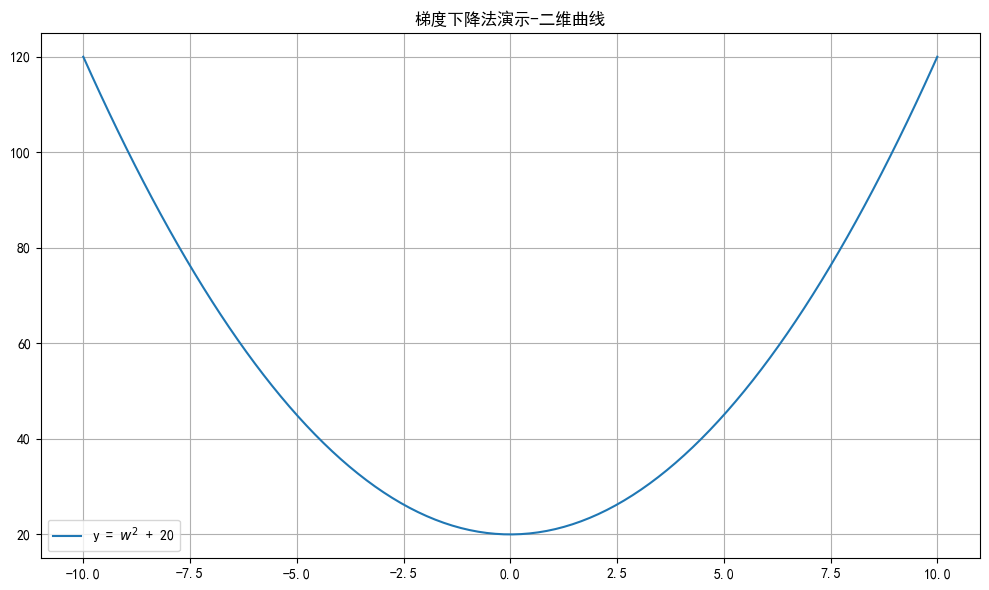

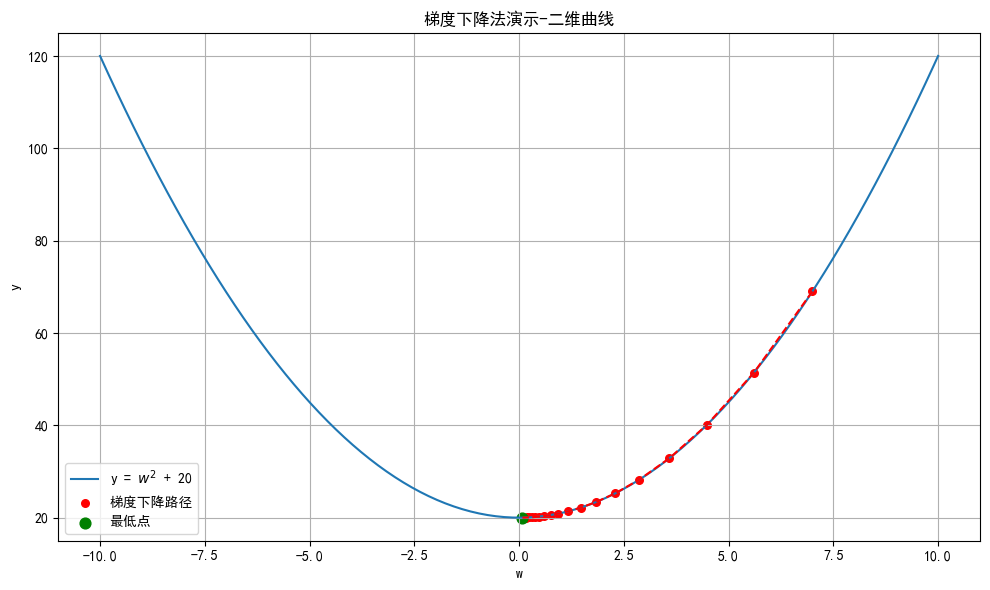

In [12]:
# 目标函数 & 导数
def f(x):
    return x**2 + 20

def grad(x):
    return 2 * x

# 准备绘图
x_vals = np.linspace(-10, 10, 200)
y_vals = f(x_vals)

plt.figure(figsize=(10,6))
plt.title("梯度下降法演示-二维曲线")
plt.plot(x_vals,y_vals, label="y = $w^{2}$ + 20")
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()

# 梯度下降参数
lr = 0.1          # learning rate
x = 7            # 初始点
steps = 20        # 迭代次数

xs = [x]          # 保存每一步的 x
ys = [f(x)]       # 保存每一步的 y

# 梯度下降过程
for i in range(steps):
    g = grad(x)
    x = x - lr * g
    xs.append(x)
    ys.append(f(x))

# 绘制函数曲线
plt.figure(figsize=(10,6))
plt.plot(x_vals, y_vals, label=r"y = $w^{2}$ + 20")

# 绘制梯度下降路径
plt.scatter(xs, ys, color='red', s=30, label="梯度下降路径")
plt.plot(xs, ys, color='red', linestyle='--')

# 最终点标注
plt.scatter(xs[-1], ys[-1], color='green', s=60, label="最低点")

plt.grid()
plt.legend()
plt.title("梯度下降法演示-二维曲线")
plt.xlabel("w")
plt.ylabel("y")
plt.tight_layout()
plt.show()

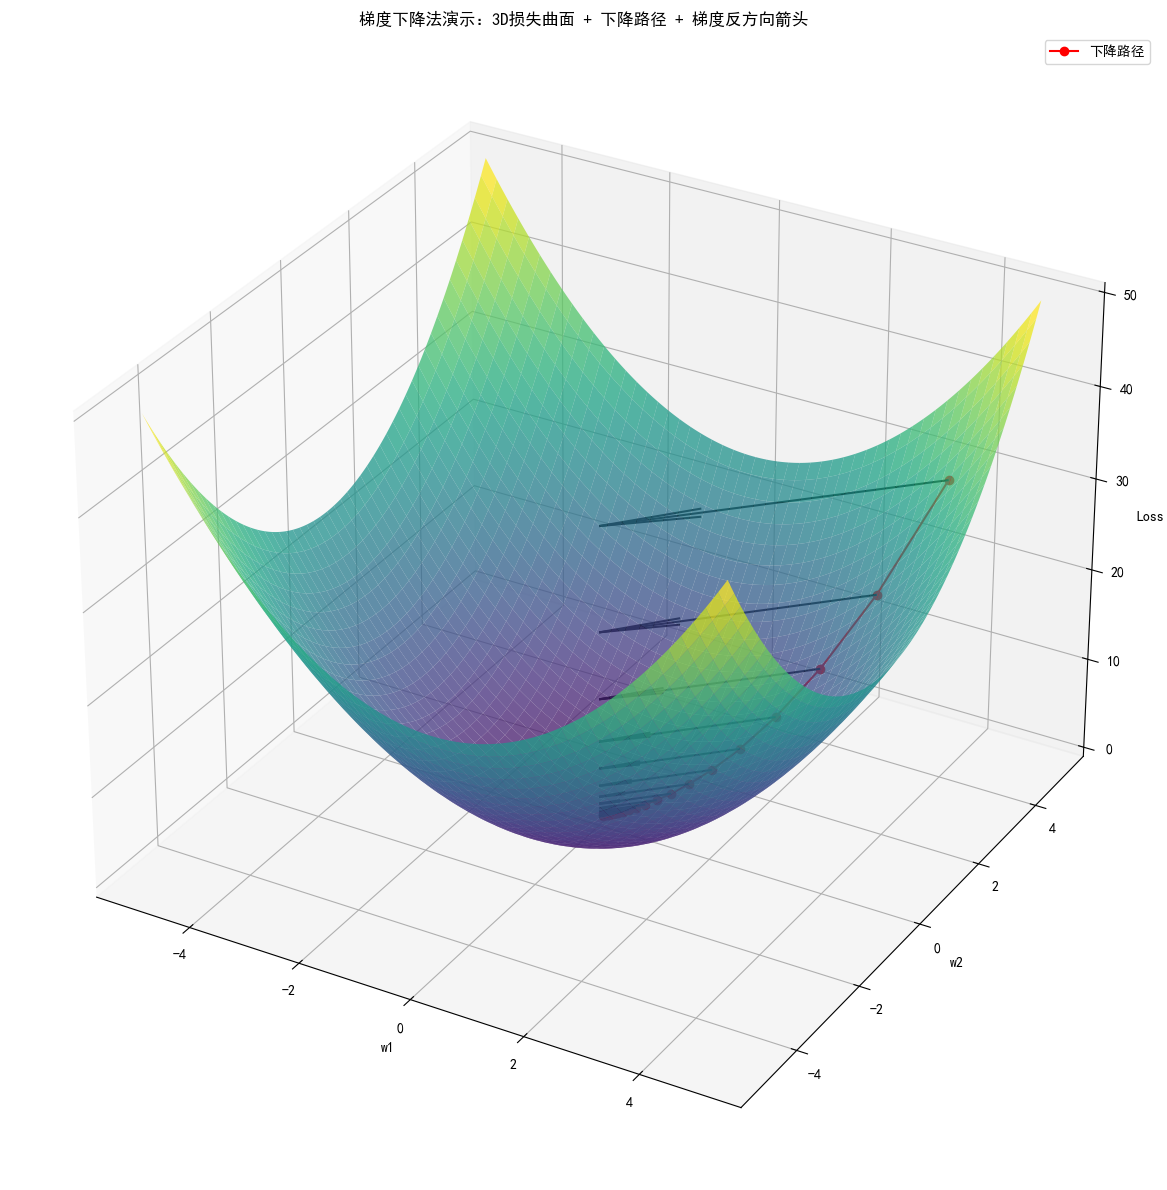

'./data/gradient_descent.gif'

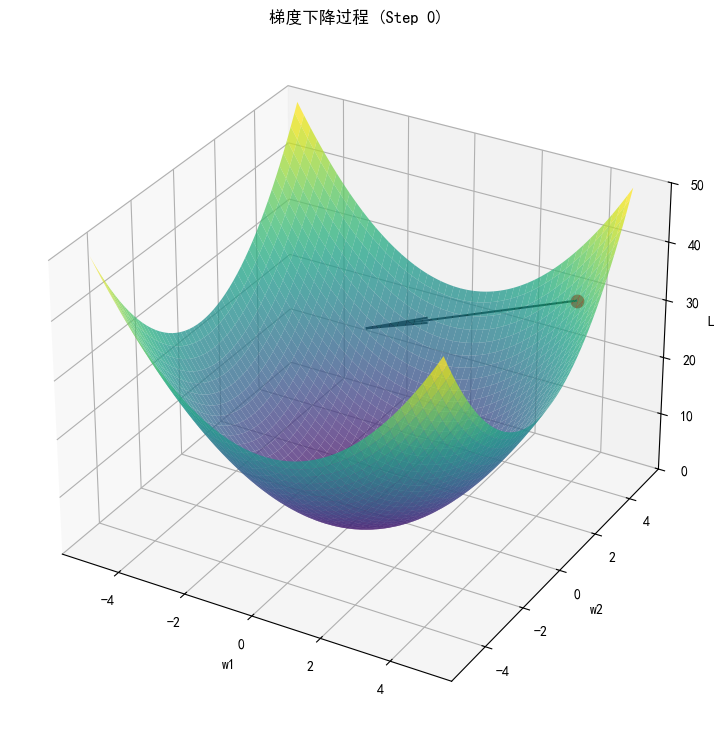

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.animation import FuncAnimation, PillowWriter

# -----------------------------
# 1. 定义损失函数和梯度
# -----------------------------
def f(x, y):
    return x**2 + y**2

def grad_f(x, y):
    return np.array([2*x, 2*y])

# -----------------------------
# 2. 创建网格用于绘制 3D 曲面
# -----------------------------
x = np.linspace(-5, 5, 200)
y = np.linspace(-5, 5, 200)
X, Y = np.meshgrid(x, y)
Z = f(X, Y)

# -----------------------------
# 3. 梯度下降
# -----------------------------
lr = 0.1
steps = 20
point = np.array([4.0, 4.0])
trajectory = [point.copy()]

for _ in range(steps):
    grad = grad_f(point[0], point[1])
    point -= lr * grad
    trajectory.append(point.copy())

trajectory = np.array(trajectory)
Z_traj = f(trajectory[:,0], trajectory[:,1])

# -----------------------------
# 4. 绘制静态图（带箭头）
# -----------------------------
fig = plt.figure(figsize=(16,12))
ax = fig.add_subplot(111, projection='3d')
ax.set_title("梯度下降法演示：3D损失曲面 + 下降路径 + 梯度反方向箭头")

# 曲面
ax.plot_surface(X, Y, Z, alpha=0.75, cmap="viridis")

# 下降路径
ax.plot(trajectory[:,0], trajectory[:,1], Z_traj,
        color='red', marker='o', label="下降路径")

# 添加地面方向箭头（-梯度方向）
for i in range(len(trajectory)):
    x, y = trajectory[i]
    dx, dy = -grad_f(x, y)     # 梯度反方向
    ax.quiver(x, y, f(x,y), dx, dy, 0, 
              length=0.5, color="black")

ax.set_xlabel("w1")
ax.set_ylabel("w2")
ax.set_zlabel("Loss")
ax.legend()

plt.tight_layout()
plt.show()

# -----------------------------
# 5. 生成 GIF 动画
# -----------------------------
fig = plt.figure(figsize=(12,9))
ax = fig.add_subplot(111, projection='3d')

def update(frame):
    ax.cla()
    ax.plot_surface(X, Y, Z, alpha=0.75, cmap="viridis")

    # 当前路径
    ax.plot(trajectory[:frame+1,0], trajectory[:frame+1,1],
            Z_traj[:frame+1], color='red')

    # 当前点
    x, y = trajectory[frame]
    z = f(x,y)
    ax.scatter(x, y, z, color="red", s=80)

    # 地面方向箭头
    dx, dy = -grad_f(x, y)
    ax.quiver(x, y, z, dx, dy, 0, color="black", length=0.5)

    ax.set_title("梯度下降过程 (Step {})".format(frame))
    ax.set_xlabel("w1")
    ax.set_ylabel("w2")
    ax.set_zlabel("Loss")
    ax.set_zlim(0, 50)

ani = FuncAnimation(fig, update, frames=len(trajectory), interval=300)

# 保存 GIF
gif_path = "./data/gradient_descent.gif"
ani.save(gif_path, writer=PillowWriter(fps=3))

gif_path


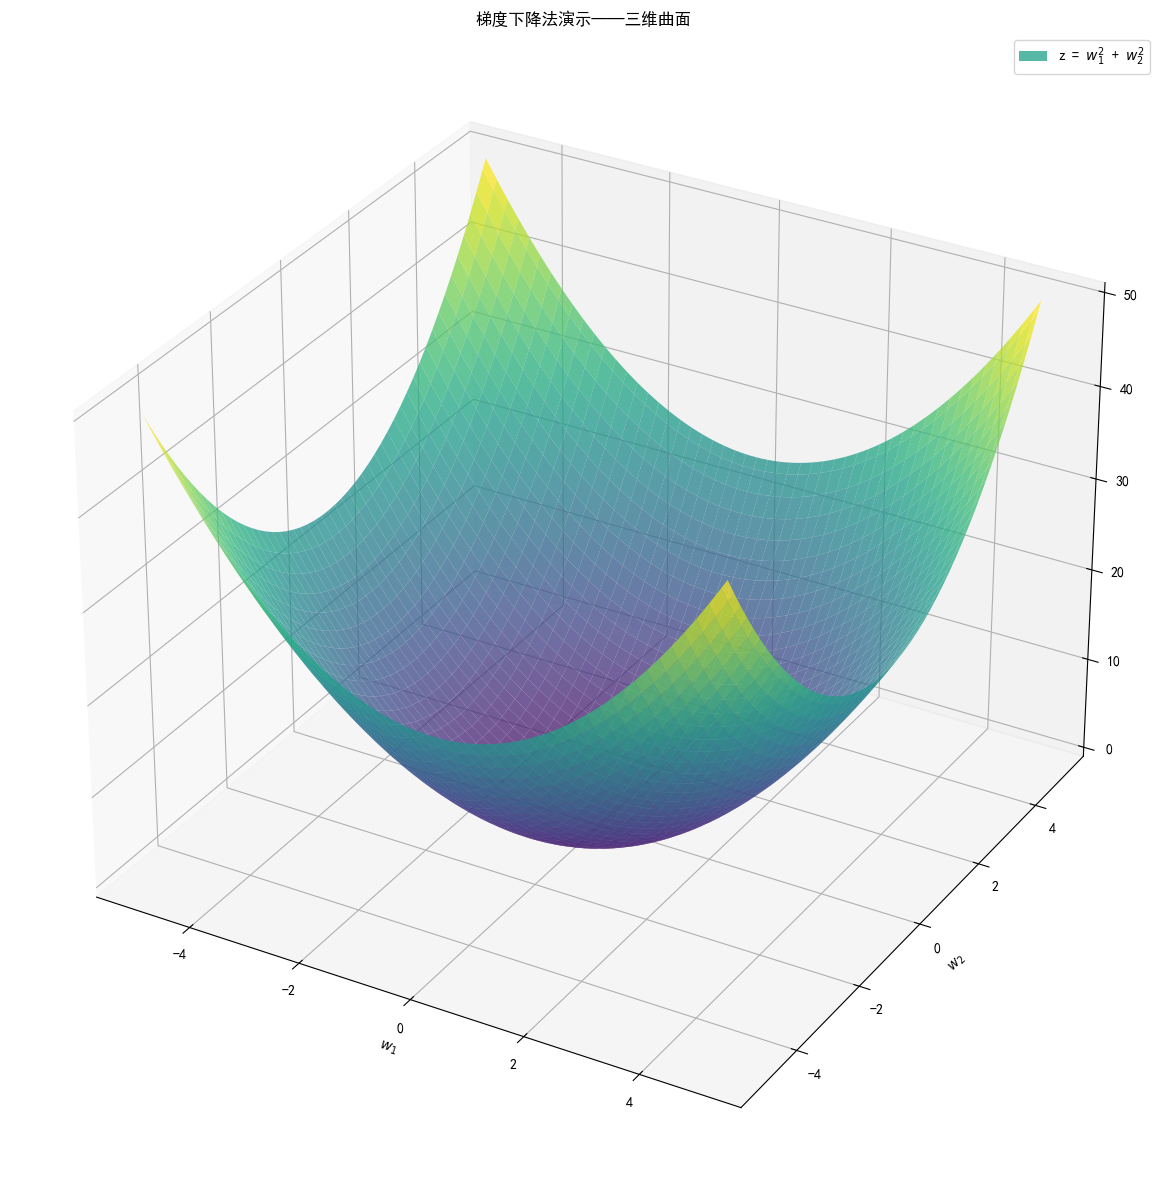

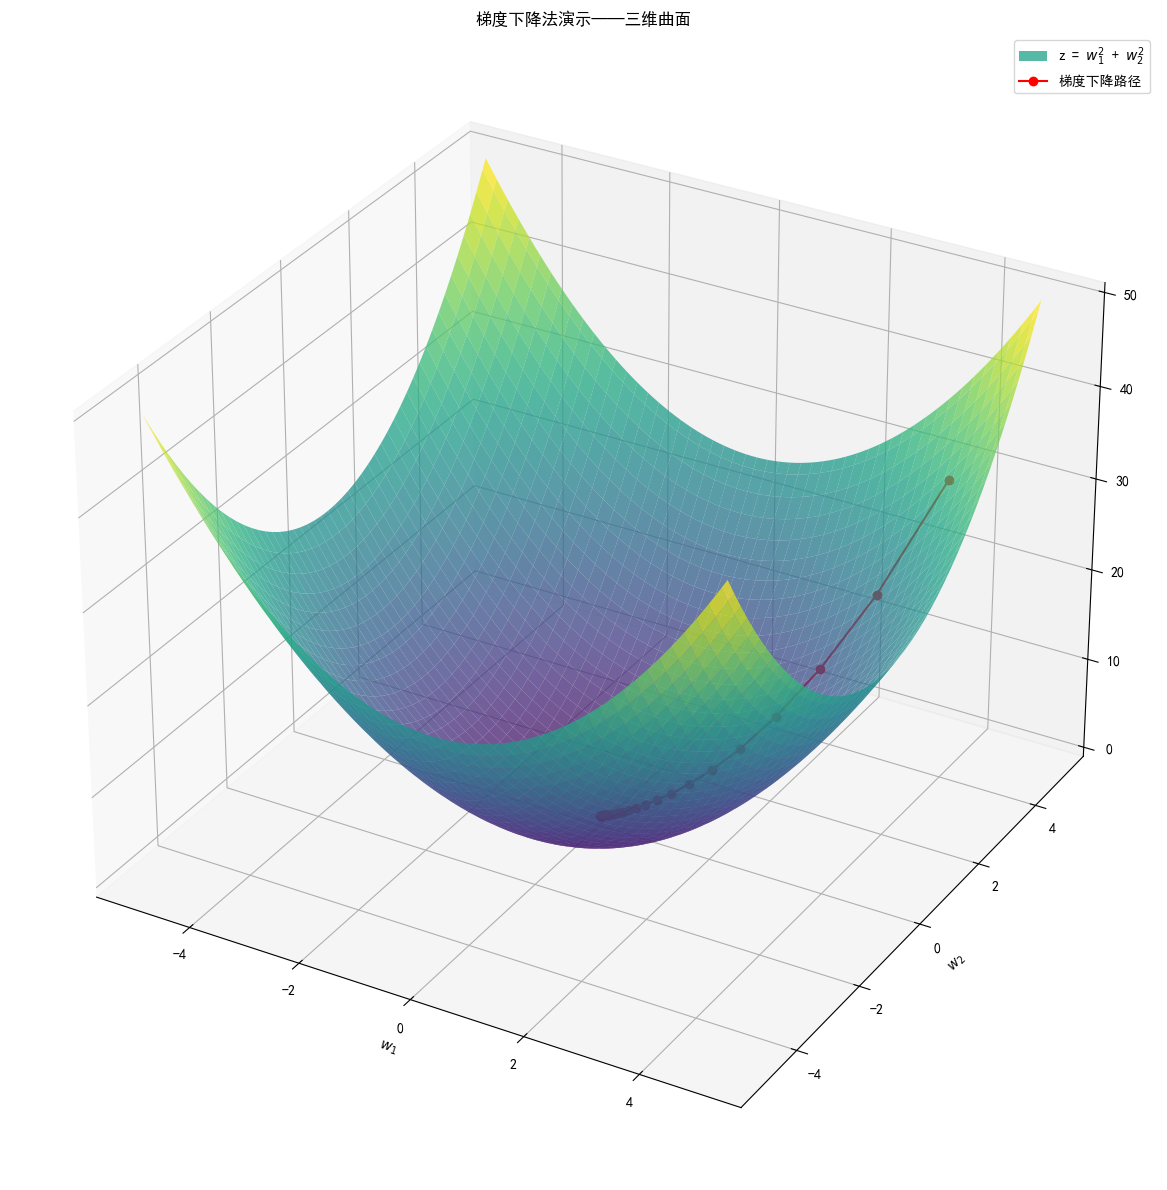

In [14]:
import numpy as np
from mpl_toolkits.mplot3d import Axes3D

# 定义函数及梯度
def f(x, y):
    return x**2 + y**2

def grad_f(x, y):
    return np.array([2*x, 2*y])

# 创建网格
x = np.linspace(-5, 5, 100)
y = np.linspace(-5, 5, 100)
X, Y = np.meshgrid(x, y)
Z = f(X, Y)

# 梯度下降初始化
lr = 0.1  # 学习率
steps = 25
point = np.array([4.0, 4.0])  # 起点
trajectory = [point.copy()]

# 梯度下降迭代
for _ in range(steps):
    grad = grad_f(point[0], point[1])
    point -= lr * grad
    trajectory.append(point.copy())

trajectory = np.array(trajectory)
Z_traj = f(trajectory[:,0], trajectory[:,1])

# 绘图
# Plot surface
fig = plt.figure(figsize=(16,12))
ax = fig.add_subplot(111, projection='3d')
ax.set_title("梯度下降法演示——三维曲面")
ax.plot_surface(X, Y, Z, alpha=0.75, cmap='viridis', label="z = $w_1^{2}$ + $w_2^{2}$")  # No colors specified
ax.set_xlabel(r"$w_1$")
ax.set_ylabel(r"$w_2$")
ax.legend()
plt.tight_layout()

fig = plt.figure(figsize=(16,12))
ax = fig.add_subplot(111, projection='3d')
ax.set_title("梯度下降法演示——三维曲面")
ax.plot_surface(X, Y, Z, alpha=0.75, cmap='viridis', label="z = $w_1^{2}$ + $w_2^{2}$")  # 半透明曲面
ax.plot(trajectory[:,0], trajectory[:,1], Z_traj, color='r', marker='o', label='梯度下降路径')

ax.set_xlabel(r"$w_1$")
ax.set_ylabel(r"$w_2$")
# ax.set_zlabel(r"z = $w_1^{2}$ + $w_2^{2}$")
ax.legend()
plt.tight_layout()
plt.show()

- 演示自动微分模块, 循环实现 计算梯度, 更新参数
    1. 定义点 w=10 requires_grad=True  dtype=torch.float32
    2. 定义函数 loss = w**2 + 20
    3. 利用梯度下降法 循环迭代1000 求最优解
        - 3.1 前向传播
        - 3.2 计算损失
        - 3.3 梯度清零 w.grad.zero_()
        - 3.4 反向传播
        - 3.5 更新参数 w.data = w.data - 0.01 * w.grad

In [ ]:
"""
案例：
    演示 自动微分模块案例 循环实现，计算梯度，更新参数

题目：
    # 求 loss = w**2 + 20 的极小值点 并打印loss是最小值时 w的值(梯度)
解题步骤：
    # 1 定义点 w=10 requires_grad=True  dtype=torch.float32
    # 2 定义函数 loss = w**2 + 20
    # 3 利用梯度下降法 循环迭代500 求最优解
        # 3.1 前向传播
        # 3.2 计算损失
        # 3.3 梯度清零 w.grad.zero_()
        # 3.4 反向传播
        # 3.5 更新参数 w.data = w.data - 0.01 * w.grad

"""
# 求 loss = w**2 + 20 的极小值点 并打印loss是最小值时 w的值(梯度)
import torch

# 1 定义点 w=10 requires_grad=True  dtype=torch.float32
# 参数1：初始值；参数2：是否自动微分/求导；参数3：元素类型
w = torch.tensor([10,20], requires_grad=True, dtype=torch.float32)
# 2 定义函数 loss = w**2 + 20
loss = w ** 2 + 20  # 求导 2w [2w1, 2w2]
# 3 利用梯度下降法 循环迭代100 求最优解
print(f"开始时,权重初始值w: {w}")
print("(0.01 * w.grad): 无")
print(f"初始值loss: {loss}")
# 记录损失均值
loss_list = []
# 循环迭代500次
for i in range(500):
    # 3.1 前向传播
    # 3.2 计算损失
    loss = w ** 2 + 20
    # 3.3 梯度清零 w.grad.zero_(), 判断非空
    if w.grad is not None:
        w.grad.zero_()
    # 3.4 反向传播 .backward()
    loss.mean().backward()
    # 3.5 更新参数 w.data = w.data - 0.01 * w.grad
    w.data = w.data - 0.01 * w.grad
    # print(f"第{i+1}次迭代, 梯度: {w.grad}")
    print(f"第{i+1}次迭代, 权重w: {w.data}, (0.01 * w.grad): {(0.01 * w.grad).data}, loss.mean(): {loss.mean().data}")
    # 添加到loss_list
    loss_list.append(loss.mean().item())

# 打印最终的结果
print(f"最终结果, 权重w: {w}, 梯度: {w.grad}, 损失均值loss.mean(): {loss.mean().data}")

初始值w: tensor([10., 20.], requires_grad=True)
初始值loss: tensor([120., 420.], grad_fn=<AddBackward0>)
开始时,权重初始值w: tensor([10., 20.], requires_grad=True)
(0.01 * w.grad): 无
初始值loss: tensor([120., 420.], grad_fn=<AddBackward0>)
第1次迭代, 权重w: tensor([ 9.9000, 19.8000]), (0.01 * w.grad): tensor([0.1000, 0.2000]), loss.mean(): 270.0
第2次迭代, 权重w: tensor([ 9.8010, 19.6020]), (0.01 * w.grad): tensor([0.0990, 0.1980]), loss.mean(): 265.0249938964844
第3次迭代, 权重w: tensor([ 9.7030, 19.4060]), (0.01 * w.grad): tensor([0.0980, 0.1960]), loss.mean(): 260.14898681640625
第4次迭代, 权重w: tensor([ 9.6060, 19.2119]), (0.01 * w.grad): tensor([0.0970, 0.1941]), loss.mean(): 255.37002563476562
第5次迭代, 权重w: tensor([ 9.5099, 19.0198]), (0.01 * w.grad): tensor([0.0961, 0.1921]), loss.mean(): 250.68617248535156
第6次迭代, 权重w: tensor([ 9.4148, 18.8296]), (0.01 * w.grad): tensor([0.0951, 0.1902]), loss.mean(): 246.0955047607422
第7次迭代, 权重w: tensor([ 9.3207, 18.6413]), (0.01 * w.grad): tensor([0.0941, 0.1883]), loss.mean(): 241.59

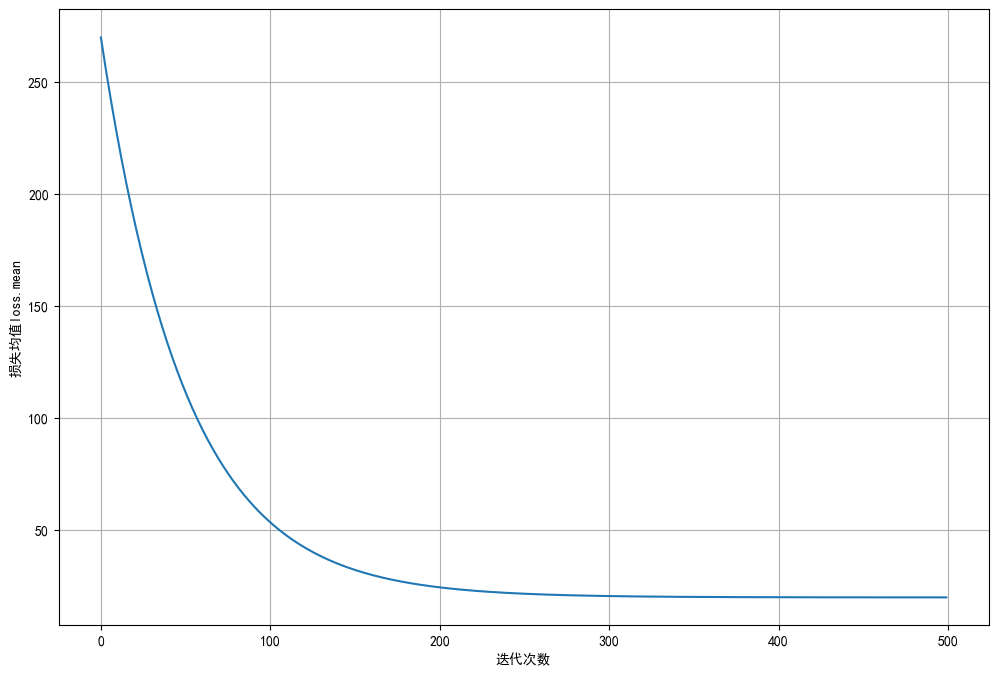

In [13]:
# 绘制损失曲线
iterations = range(500)
plt.figure(figsize=(12,8))
plt.plot(iterations,loss_list)
plt.xlabel("迭代次数")
plt.ylabel("损失均值loss.mean")
plt.grid()
plt.show()

## 常见面试题

### 1. 矩阵A形状(4,5),矩阵B形状(5,4),A和B的矩阵乘法结果形状是什么？
  - 矩阵A 和 矩阵B 的矩阵乘法结果形状为 (4,4)

---

### 2. pytorch中求均值、求指数、求对数的API是什么？
  - **均值**：`torch.mean()` 或 `tensor.mean()`
  - **指数**：`torch.exp()` 或 `tensor.exp()`
  - **对数**：`torch.log()` 或 `tensor.log()`

---

### 3. reshape和view有什么区别？
  - reshape 和 view 都可以改变张量的形状，并且不改变元素顺序。
  - 主要区别：
    - 1.连续性要求上，view 只能作用于 连续张量，非连续张量则会报错；reshape 可以处理 连续或非连续张量，必要时会复制数据。
    - 2.共享内存上，view 返回的张量 共享原张量内存，修改会影响原张量；reshape 不一定共享内存，有时会复制数据。

---

### 4. pytorch中哪个属性来设置开启梯度计算，哪个属性来获取梯度，哪个方法来计算梯度？
  - 开启梯度计算，使用`requires_grad=True`
  - 获取梯度，使用`tensor.grad`
  - 计算梯度，使用`loss.backward()`

## 代码作业

- 1.使用torch.tensor()创建两个形状为(3,4)的张量t1和t2，计算(t1+t2-2)*2, 并打印。
- 2.使用torch.arange创建一个形状为(3,4)的张量t1,创建一个形状为(3,4)的随机张量t2，计算t1*t2,然后将t2转换形状为(4,3)，注意不要改变t2中元素顺序，计算t1@t2,并打印。
- 3.使用torch.randint()创建一个形状为(3,4)的随机整数张量,求所有元素的均值 和 第1个轴的均值，并打印。(注意元素类型转换)
- 4.使用torch.randint()创建一个形状为(3,4)的张量，获取第2个轴的 索引为1的所有数据，然后获取第二个轴的 索引为1的 大于5的元素 对应的 第一个轴的数据，并打印。
- 5.创建两个形状为(3,4)的随机张量t1和t2，都转换形状为(4,3), 然后按0轴进行拼接，得到形状为(8,3)的张量，并打印。
- 6.创建一个形状为(3)的随机张量w，开启requires_grad, 计算loss = w**2 + 20, 使用loss.mean().backward()获取梯度，并打印梯度w.grad。（尝试手动计算梯度）